In [2]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [3]:
case_name = "MPHYS AT10"
#User choice:
solveConduction = True
plot_at_z1 = []

########## Thermal hydraulics parameters ##########
## Geometric parameters
#User choice:
solveConduction = True
zPlotting = []

If = 8
I1 = 3
# Sensitivity to the meshing parameters
Iz1 = 25 # number of control volumes in the axial direction, added 70 for comparison with GeN-Foam
# Iz1 = 10, 20, 40, 50, 70, 80 and 160 are supported for the DONJON solution


########## Choice of Thermalhydraulics correlation ##########
voidFractionCorrel = 'EPRIvoidCorrel' # 'modBestion', 'HEM1', 'GEramp', 'EPRIvoidModel'
frfaccorel = "Churchill" # 'base', 'blasius', 'Churchill', 'Churchill_notOK' ?
P2Pcorel = "lockhartMartinelli" # 'base', 'HEM1', 'HEM2', 'MNmodel', "lockhartMartinelli"
numericalMethod = "FVM" # "FVM": Solves the system using matrix inversion with preconditioning.
                        # "GaussSiedel" : Applies the Gauss-Seidel iterative solver.
                        # "BiCG" : Uses the BiConjugate Gradient method for solving non-symmetric or indefinite matrices.
                        # "BiCGStab" : Applies the BiCGStab (BiConjugate Gradient Stabilized) method to ensure faster and more stable convergence.

########## Thermal hydraulics parameters ##########
## Geometric parameters
canalType = "square" # "square", "cylindrical"
pitch =1.295e-2 #1.295e-2 # m : ATRIUM10 pincell pitch   0.0126 #
fuelRadius = 0.4435e-2 # m : fuel rod radius
#gapRadius = fuelRadius + 0.000001 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
gapRadius = 0.4520e-2 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
cladRadius = 0.5140e-2 # m : clad external radius
height = 1.555 # m : height : 3.8 m : active core height in BWRX-300 SMR, 1.555 m : for GF comparison.


## Fluid parameters
# T_inlet, T_outlet = 270, 287 Celcius
#tInlet = 270 + 273.15 # K, for BWRX-300 SMR core, try lowering the inlet temperature to set boiling point back and reduce the void fraction increase in the first few cm
tInlet = 270 + 273.15 # K, for BWRX-300 SMR core
#Nominal operating pressure = 7.2 MPa (abs)
pOutlet =  7.2e6 # Pa 
# Nominal coolant flow rate = 1530 kg/s
massFlowRate = 8.407 * 10**(-2) #1530  / (200*91)  # kg/s

## Material parameters
kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
Hgap = 10000 
#Hgap = 9000
kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
# k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity

############ Nuclear Parameters ###########
# Number of fuel rods and assemblies for a small modular Boiling Water Reactor core

def main():
    qFiss = 400000000
    qFiss_init_4 = []
    for i in range(Iz1):
        qFiss_init_4.append(qFiss)

    case4 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_4, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)
    

    qFiss = 200000000
    qFiss_init_2 = []
    for i in range(Iz1):
        qFiss_init_2.append(qFiss)
        
    case2 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_2, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)

    qFiss = 100000000
    qFiss_init_1 = []
    for i in range(Iz1):
        qFiss_init_1.append(qFiss)
    
    case1 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_1, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)
    
    qFiss = 40000000
    qFiss_init_0 = []
    for i in range(Iz1):
        qFiss_init_0.append(qFiss)
    
    caseMono = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_0, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)
    
    caseMerge = [case4, case2, case1, caseMono]#, case1, case2, case3, case4, case5, case6, case7, case8]
    return caseMerge

caseMerge = main()
#if __name__ == "__main__":
#    cProfile.run('main()', filename='profiling_result.prof')

$$$---------- THM: prototype, case treated : Initialization of BWR Pincell equivalent canal.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.555 m with 25 axial elements.
self.I_z: 25
self.qFlow: 0.08407
self.pOutlet: 7200000.0
self.Lf: 1.555
self.r_f: 0.004435
self.clad_r: 0.00514
self.r_w: 0.01295
self.Dz: 0.0622
self.dt: 0
Courant number: 0.0
Numerical Method FVM
Hydraulic diameter: [0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763,

c:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\THM_waterProp.py:556: RuntimeWarning: divide by zero encountered in scalar divide
  return self.U[i] - (self.voidFractionTEMP[i] / ( 1 - self.voidFractionTEMP[i])) * (self.rhogTEMP[i] / self.rhoTEMP[i]) * self.VgjPrimeTEMP[i]
c:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\THM_waterProp.py:571: RuntimeWarning: invalid value encountered in sqrt
  return 1 + 1/np.sqrt(X) + 20/X


Convergence test number 0, RES: errEPS: 2.1897617175581803, errRHO: 5.029898283261902, errQua: 4.585888020803032
Convergence test number 1, RES: errEPS: 0.072468917517642, errRHO: 0.1771151097182156, errQua: 0.000746369915190023
Convergence test number 2, RES: errEPS: 0.008438524310731178, errRHO: 0.0097828864815785, errQua: 0.000969535931172679
Convergence test number 3, RES: errEPS: 0.00036687616970096517, errRHO: 0.000666392980351981, errQua: 0.0002297664703892411
Convergence test number 4, RES: errEPS: 2.9100731387236683e-05, errRHO: 6.43544742081901e-05, errQua: 1.8800339157306978e-05
Convergence reached at iteration number: 4
$$---------- Setting up FDM_HeatConductionInFuelPin class for z = 0.0311 m, Qfiss(z) = 291809174.3226133 W/m^3 and T_surf(z) = 603.4880411265531 K
$---------- Solving for T(r) using the Finite Difference Method, at z = 0.0311.
$$---------- Setting up FDM_HeatConductionInFuelPin class for z = 0.09330000000000001 m, Qfiss(z) = 291809174.3226133 W/m^3 and T_sur

In [4]:

class GFPlotter():
    def __init__(self, caseList, directory_path, case_name, second_path = ""):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height

        self.data_dict_list = []
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def plotCase(self):
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        labelTitle = 'THM_prototype'
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)

        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GF: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)

        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"THM_prototype {self.caseList[i].convection_sol.frfaccorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p_rgh, label="GF P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GF")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            print(f"Reading file: {file_path}")
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    #end = start + 74
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        #end = start
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid'])#+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour'])#+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        #self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)
        self.alpha_liquid = self.alpha_liquid/(1-self.struture_fraction)
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = (1-self.alpha_vapour) * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        for i in range(len(self.rho_vapour)):
            if np.isnan(self.rho_vapour[i]):
                self.rho_vapour[i] = 0
            if np.isnan(self.rho_liquid[i]):
                self.rho_liquid[i] = 0
        print(f"rho_liquid GeN-Foam: {self.rho_liquid}")
        print(f"rho_vapour GeN-Foam: {self.rho_vapour}")
        self.rho_mixture = self.rho_liquid + self.rho_vapour

        self.T_mixture = (1-self.alpha_vapour) * self.T_liquid + self.alpha_vapour * self.T_vapour

    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        if len(self.caseList) == 1:
            labelTitle = 'THM_prototype'
        labelTitle = 'THM_prototype'
        title = ""#f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        
        fig0, ax0 = plt.subplots()
        for i in range(len(self.caseList)):
            ax0.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax0.set_xlabel("Axial position in m")
        ax0.set_ylabel("Quality")
        ax0.set_title(f"{title}")
        ax0.grid()
        ax0.legend(loc="best")
        fig0.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        #ax1.step(self.zList, self.T_liquid, label="GF T.liquid")
        #ax1.step(self.zList, self.T_vapour, label="GF T.vapour")
        ax1.step(self.zList, self.T_mixture, label="GF")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GF")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GeN-Foam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GF")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GF")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GF")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"THM_prototype {self.caseList[i].convection_sol.frfaccorel} {self.caseList[i].convection_sol.P2Pcorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GF")
        ax4.step(self.zList, self.p_rgh, label="GF P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GF")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GF")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.step(self.zList, self.U_mixture, label="GF")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.step(self.zList, self.Re_liquid_structure, label="GF")
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GF")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def computeErrors(self):
        self.error_T_abs = []
        self.error_T_rel = []
        self.error_p_abs = []
        self.error_p_rel = []
        self.error_rho_abs = []
        self.error_rho_rel = []
        self.error_U_abs = []
        self.error_U_rel = []
        self.error_Re_abs = []
        self.error_Re_rel = []
        self.error_eps_abs = []
        self.error_eps_rel = []

        for i in range(len(self.caseList)):
            self.error_T_abs.append((self.T_mixture - self.caseList[i].convection_sol.T_water))
            self.error_T_rel.append(100*self.error_T_abs[-1]/(self.T_mixture))
            self.error_p_abs.append((self.p - self.caseList[i].convection_sol.P[-1]))
            self.error_p_rel.append(100*self.error_p_abs[-1]/(self.p))
            self.error_rho_abs.append(self.rho_mixture - self.caseList[i].convection_sol.rho[-1])
            self.error_rho_rel.append(100*self.error_rho_abs[-1]/(self.rho_mixture))
            self.error_U_abs.append((self.U_mixture - self.caseList[i].convection_sol.U[-1]))
            self.error_U_rel.append(100*self.error_U_abs[-1]/(self.U_mixture))
            self.error_Re_abs.append((self.Re_liquid_structure - self.caseList[i].convection_sol.Rel))
            self.error_Re_rel.append(100*self.error_Re_abs[-1]/(self.Re_liquid_structure))
            self.error_eps_abs.append((self.alpha_vapour - self.caseList[i].convection_sol.voidFraction[-1]))
            self.error_eps_rel.append(self.error_eps_abs[-1]/(self.alpha_vapour))

            

    def plotErrorsPressure(self):
        fig, ax = plt.subplots()
        for i in range(len(self.caseList)):
            print(self.error_p_abs)
            ax.step(self.caseList[i].convection_sol.z_mesh, self.error_p_abs[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax.set_xlabel("Axial position in m")
        ax.set_ylabel("Absolute error in Pa")
        ax.set_title("Absolute error in pressure")
        ax.grid()
        ax.legend(loc="best")
        fig.savefig(rf'result\{self.case_name}\error_p_abs.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.error_p_rel[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Relative error in %")
        ax1.set_title("Relative error in pressure")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\error_p_rel.png', bbox_inches='tight')

        plt.show()

        for i in range(len(self.caseList)):
            print(f"Mean relative error in pressure: {np.mean(self.error_p_rel[i])}, max relative error in pressure {np.max(self.error_p_rel[i])} for {self.caseList[i].convection_sol.frfaccorel}, {self.caseList[i].convection_sol.P2Pcorel}")


In [5]:
def readTPF(file_path):
    # Charger les données
    df = pd.read_csv(file_path, delimiter=',', skipinitialspace=True)
    z = df['zPosition'].astype(float).tolist()
    # Convertir les colonnes de température en float
    TempVap = df['TempVap'].astype(float).tolist()
    TempLiq = df['TempLiq'].astype(float).tolist()
    TempFuelC = df['TempFuelC'].astype(float).tolist()
    TempStru = df['TempStru'].astype(float).tolist()
    Void = df['Void'].astype(float).tolist()
    Pressure = df['Pressure'].astype(float).tolist()
    VelzVap = df['VelzVap'].astype(float).tolist()
    VelzLiq = df['VelzLiq'].astype(float).tolist()

    for i in range(len(z)):
        TempVap[i] = TempVap[i] + 273.15
        TempLiq[i] = TempLiq[i] + 273.15
        TempFuelC[i] = TempFuelC[i] + 273.15
        TempStru[i] = TempStru[i] + 273.15
        
    return z, TempVap, TempLiq, TempFuelC, TempStru, Void, Pressure, VelzVap, VelzLiq

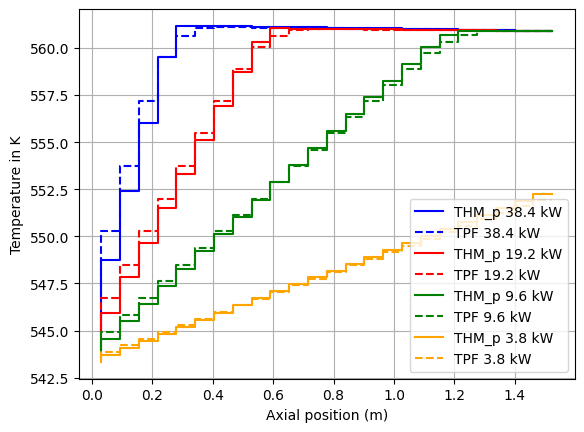

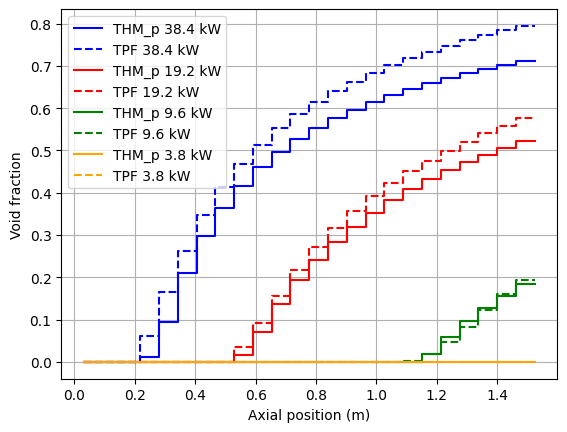

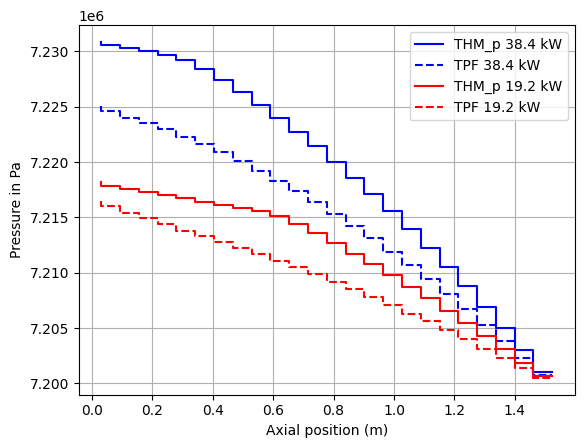

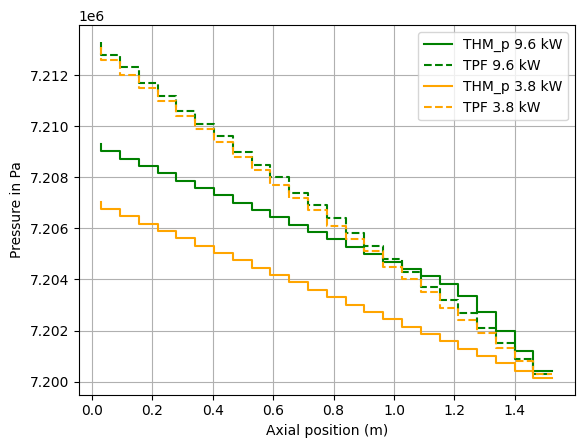

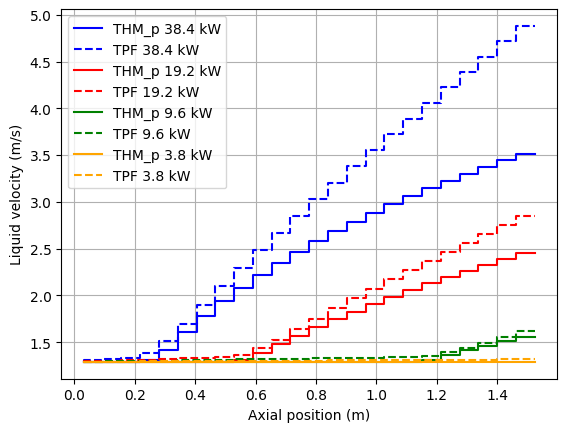

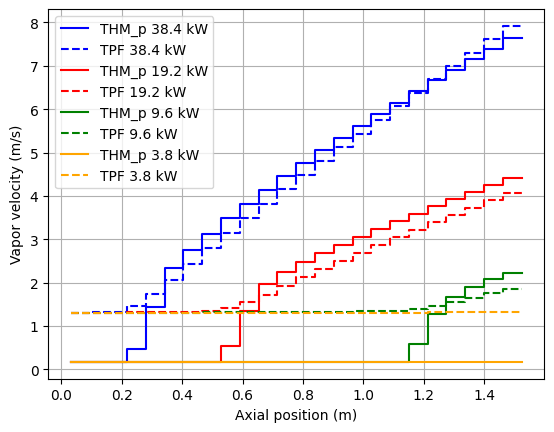

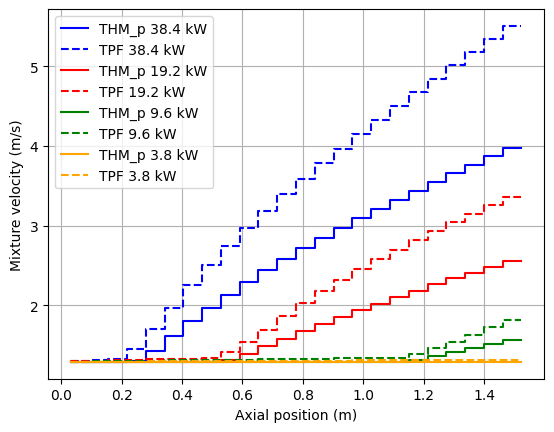

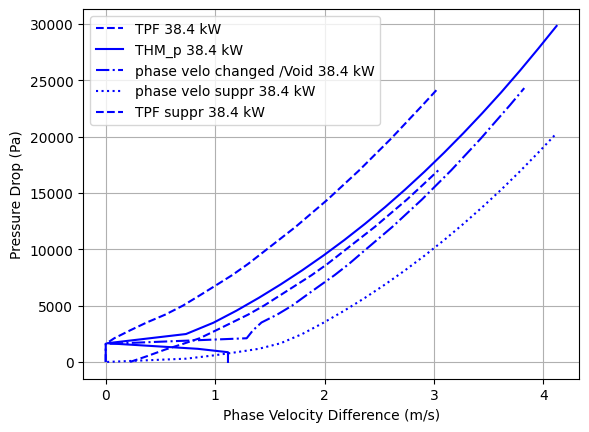

In [8]:
z, TempVap, TempLiq, TempFuelC, TempStru, Void, Pressure, VelzVap, VelzLiq = [], [], [], [], [], [], [], [], []

case = [4, 2, 1, 0]
powers = [38.4, 19.2, 9.6, 3.8]
for i in case:
    X = readTPF(rf"C:\Users\cleme\OneDrive\Documents\Poly\BWR\THM_prototype\TPF\graph_axial_{i}e9W.txt")
    z.append(X[0])
    TempVap.append(X[1])
    TempLiq.append(X[2])
    TempFuelC.append(X[3])
    TempStru.append(X[4])
    Void.append(X[5])
    Pressure.append(X[6])
    VelzVap.append(X[7])
    VelzLiq.append(X[8])

colors = ['blue', 'red', 'green', 'orange']

fig, ax = plt.subplots()
for i in range(len(caseMerge)):
    ax.step(caseMerge[i].convection_sol.z_mesh, caseMerge[i].convection_sol.T_water, label=f"THM_p {powers[i]} kW", color=colors[i])
    #ax.step(z[i], TempVap[i], label=f"TPF {powers[i]} kW", linestyle='--', color = colors[i])
    ax.step(z[i], TempLiq[i], label=f"TPF {powers[i]} kW", linestyle='--', color = colors[i])
ax.set_xlabel("Axial position (m)")
ax.set_ylabel("Temperature in K")
ax.grid()
ax.legend(loc="best")

fig1, ax1 = plt.subplots()
for i in range(len(caseMerge)):
    ax1.step(caseMerge[i].convection_sol.z_mesh, caseMerge[i].convection_sol.voidFraction[-1], label=f"THM_p {powers[i]} kW", color=colors[i])
    ax1.step(z[i], Void[i], label=f"TPF {powers[i]} kW", linestyle='--', color = colors[i])
ax1.set_xlabel("Axial position (m)")
ax1.set_ylabel("Void fraction")
ax1.grid()
ax1.legend(loc="best")

fig2, ax2 = plt.subplots()
for i in [0,1]:
    ax2.step(caseMerge[i].convection_sol.z_mesh, caseMerge[i].convection_sol.P[-1], label=f"THM_p {powers[i]} kW", color=colors[i])
    ax2.step(z[i], Pressure[i], label=f"TPF {powers[i]} kW", linestyle='--', color = colors[i])
ax2.set_xlabel("Axial position (m)")
ax2.set_ylabel("Pressure in Pa")
ax2.grid()
ax2.legend(loc="best")

fig23, ax23 = plt.subplots()
for i in [2,3]:
    ax23.step(caseMerge[i].convection_sol.z_mesh, caseMerge[i].convection_sol.P[-1], label=f"THM_p {powers[i]} kW", color=colors[i])
    ax23.step(z[i], Pressure[i], label=f"TPF {powers[i]} kW", linestyle='--', color = colors[i])
ax23.set_xlabel("Axial position (m)")
ax23.set_ylabel("Pressure in Pa")
ax23.grid()
ax23.legend(loc="best")


fig3, ax3 = plt.subplots()
for i in range(len(caseMerge)):
    ax3.step(caseMerge[i].convection_sol.z_mesh, caseMerge[i].convection_sol.Ul, label=f"THM_p {powers[i]} kW", color=colors[i])
    ax3.step(z[i], VelzLiq[i], label=f"TPF {powers[i]} kW", linestyle='--', color = colors[i])
ax3.set_xlabel("Axial position (m)")
ax3.set_ylabel("Liquid velocity (m/s)")
ax3.grid()
ax3.legend(loc="best")

fig4, ax4 = plt.subplots()
for i in range(len(caseMerge)):
    ax4.step(caseMerge[i].convection_sol.z_mesh, caseMerge[i].convection_sol.Ug, label=f"THM_p {powers[i]} kW", color=colors[i])
    ax4.step(z[i], VelzVap[i], label=f"TPF {powers[i]} kW", linestyle='--', color = colors[i])
ax4.set_xlabel("Axial position (m)")
ax4.set_ylabel("Vapor velocity (m/s)")
ax4.grid()
ax4.legend(loc="best")

fig6, ax6 = plt.subplots()
for i in range(len(caseMerge)):
    ax6.step(caseMerge[i].convection_sol.z_mesh, caseMerge[i].convection_sol.U[-1], label=f"THM_p {powers[i]} kW", color=colors[i])
    ax6.step(z[i], [Void[i][j]*VelzLiq[i][j] + (1-Void[i][j])*VelzVap[i][j] for j in range(len(Void[i]))], label=f"TPF {powers[i]} kW", linestyle='--', color = colors[i])
ax6.set_xlabel("Axial position (m)")
ax6.set_ylabel("Mixture velocity (m/s)")
ax6.grid()
ax6.legend(loc="best")

fig5, ax5 = plt.subplots()
for i in [0]:
    phase_velocity_diff_TPF = np.abs(np.array(VelzLiq[i]) - np.array(VelzVap[i]))
    pressure_drop_TPF = [abs(Pressure[i][j] - Pressure[i][0]) for j in range(len(Pressure[i]))]
    phase_velocity_diff_THM = np.abs(np.array(caseMerge[i].convection_sol.Ul) - np.array(caseMerge[i].convection_sol.Ug))
    pressure_drop_THM = [abs(caseMerge[i].convection_sol.P[-1][j] - caseMerge[i].convection_sol.P[-1][0]) for j in range(len(caseMerge[i].convection_sol.P[-1]))]
    phase_velocity_diff_TPF_to_THM = [phase_velocity_diff_TPF[j] / (Void[i][j]) for j in range(len(phase_velocity_diff_TPF))]
    phase_velocity_diff_THM_suppr = np.abs(np.array(caseMerge[i].convection_sol.Ul[5:]) - np.array(caseMerge[i].convection_sol.Ug[5:]))
    phase_velocity_diff_TPF_suppr = np.abs(np.array(VelzLiq[i][5:]) - np.array(VelzVap[i][5:]))
    pressure_drop_THM_suppr = [abs(caseMerge[i].convection_sol.P[-1][j] - caseMerge[i].convection_sol.P[-1][0]) for j in range(len(caseMerge[i].convection_sol.P[-1][5:]))]
    pressure_drop_TPF_suppr = [abs(Pressure[i][j] - Pressure[i][0]) for j in range(len(Pressure[i][5:]))]
    ax5.plot(phase_velocity_diff_TPF, pressure_drop_TPF, label=f"TPF {powers[i]} kW", linestyle='--', color = colors[i])
    ax5.plot(phase_velocity_diff_THM, pressure_drop_THM, label=f"THM_p {powers[i]} kW", color=colors[i])
    ax5.plot(phase_velocity_diff_TPF_to_THM, pressure_drop_TPF, label=f"phase velo changed /Void {powers[i]} kW", color=colors[i], linestyle='-.')
    ax5.plot(phase_velocity_diff_THM_suppr, pressure_drop_THM_suppr, label=f"phase velo suppr {powers[i]} kW", color=colors[i], linestyle=':')
    ax5.plot(phase_velocity_diff_TPF_suppr, pressure_drop_TPF_suppr, label=f"TPF suppr {powers[i]} kW", linestyle='--', color = colors[i])
ax5.set_xlabel("Phase Velocity Difference (m/s)")
ax5.set_ylabel("Pressure Drop (Pa)")
ax5.grid()
ax5.legend(loc="best")

plt.show()




In [ ]:
from scipy.stats import pearsonr
from scipy import interpolate

def compute_metrics(y1, y2):
    # Écarts absolus
    abs_diff = np.abs(y1 - y2)
    
    # Écarts relatifs (gestion des divisions par zéro)
    rel_diff = []
    for i in range(len(y1)):
        if y1[i] != 0:
            rel_diff.append(abs_diff[i] / abs(y1[i]))
        else:
            rel_diff.append(0)

    rel_diff = np.array(rel_diff)
    
    return {
        'MAE': np.mean(abs_diff),  # Erreur Absolue Moyenne
        'RMSE': np.sqrt(np.mean(abs_diff**2)),  # Racine de l'Erreur Quadratique Moyenne
        'Max Error': np.max(abs_diff),  # Écart Maximal
        'Mean Relative Error (%)': np.mean(rel_diff)*100,  # Erreur Relative Moyenne
    }

def plot_comparison(z1, z2, y1, y2, title):
    plt.figure(figsize=(10, 6))
    
    # Courbes superposées
    plt.subplot(2, 1, 1)
    plt.plot(z1, y1, label='Code 1')
    plt.plot(z2, y2, '--', label='Code 2')
    plt.title(title)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def align_and_compare(z1, y1, z2, y2):
    """Align two datasets through interpolation and compute metrics"""
    # Création d'un domaine commun
    z_min = max(min(z1), min(z2))
    z_max = min(max(z1), max(z2))
    
    if z_min >= z_max:
        print("Avertissement : Pas de chevauchement spatial entre les jeux de données")
        return None, None, None
    
    # Interpolation sur une grille commune dense
    z_common = np.linspace(z_min, z_max, max(len(z1), len(z2)))
    
    # Interpolation cubique pour préserver les tendances
    f1 = interpolate.interp1d(z1, y1, kind='cubic', fill_value="extrapolate")
    f2 = interpolate.interp1d(z2, y2, kind='cubic', fill_value="extrapolate")
    
    return z_common, f1(z_common), f2(z_common)

print("Analyse comparative des résultats entre le code 1 et le code 2")
powers = [38.4, 19.2, 9.6, 3.8]
data = {}


# Structure de données exemple
for i in range(len(powers)):
    name = f"{powers[i]}kW"
    data[name] = {
            'TPF': {'z': z[i], 'Temperature': TempLiq[i], 'VoidFraction': Void[i], 'Pression': Pressure[i], 'VelzLiq': VelzLiq[i], 'VelzVap': VelzVap[i]},  # Données code 1
            'THM': {'z': caseMerge[i].convection_sol.z_mesh, 'Temperature': caseMerge[i].convection_sol.T_water, 'VoidFraction': caseMerge[i].convection_sol.voidFraction[-1], 'Pression': caseMerge[i].convection_sol.P[-1], 'VelzLiq': caseMerge[i].convection_sol.Ul, 'VelzVap': caseMerge[i].convection_sol.Ug}  # Données code 2
        }

# Analyse comparative
results = {}

""" for puissance in data:
    print(f"Analyse comparative pour {puissance}")
    results[puissance] = {}
    z2 = data[puissance]['THM']['z']
    z1 = data[puissance]['TPF']['z']
    
    for variable in data[puissance]['TPF']:
        print(f'{variable}')
        y1 = np.array(data[puissance]['TPF'][variable])
        y2 = np.array(data[puissance]['THM'][variable])
        
        # Alignement des données
        #z_common, y1_aligned, y2_aligned = align_and_compare(z1, y1, z2, y2)

        # Calcul des métriques
        results[puissance][variable] = compute_metrics(y1, y2)
        
        # Génération des graphiques
        #plot_comparison(z_common, z_common, y1_aligned, y2_aligned, f"{variable} - {puissance}")

    # Affichage synthétique des résultats
df_results = pd.concat({k: pd.DataFrame(v).T for k, v in results.items()}, axis=1)
print(df_results.round(5)) """

for puissance in data:
    print(f"Analyse comparative pour {puissance}")
    results[puissance] = {}
    z2 = data[puissance]['THM']['z']
    z1 = data[puissance]['TPF']['z']
    
    for variable in data[puissance]['TPF']:
        y1 = np.array(data[puissance]['TPF'][variable])
        y2 = np.array(data[puissance]['THM'][variable])

        if variable == 'VoidFraction':
            ERROR = abs(y1 - y2)
        else: 
            ERROR = abs(y1 - y2)/y1

        RMS = np.sqrt(np.mean(ERROR**2))*100
        MAX = np.max(ERROR)*100
        print(f'RMS {variable}: {RMS}')
        print(f'MAX {variable}: {MAX}')

Analyse comparative des résultats entre le code 1 et le code 2
Analyse comparative pour 38.4kW
RMS z: 1.0888369777893927e-14
MAX z: 2.0999111492815523e-14
RMS Temperature: 0.10664416408947607
MAX Temperature: 0.3124778333928377
RMS VoidFraction: 6.070293050552953
MAX VoidFraction: 8.217875338754654
RMS Pression: 0.06748237348675062
MAX Pression: 0.09535555289240835
RMS VelzLiq: 16.240754428577578
MAX VelzLiq: 28.06534648288444
RMS VelzVap: 38.013014110949236
MAX VelzVap: 87.08609667149985
Analyse comparative pour 19.2kW
RMS z: 1.0888369777893927e-14
MAX z: 2.0999111492815523e-14
RMS Temperature: 0.06309170862628341
MAX Temperature: 0.1562895911873601
RMS VoidFraction: 3.1490138378550214
MAX VoidFraction: 5.420633241162964
RMS Pression: 0.03736158620298376
MAX Pression: 0.055224691621101225
RMS VelzLiq: 7.310698365827564
MAX VelzLiq: 13.898714659996287
RMS VelzVap: 54.539465588907255
MAX VelzVap: 87.1688053378026
Analyse comparative pour 9.6kW
RMS z: 1.0888369777893927e-14
MAX z: 2.0999

In [ ]:
powers = [38.4, 19.2, 9.6, 3.8]

for i in range(len(powers)):
    print(f'Power = {powers[i]} kW: ') 
    print(f'Ug: {caseMerge[i].convection_sol.Ug}')
    print(f'Ul: {caseMerge[i].convection_sol.Ul}')
    print(f'Void fraction: {caseMerge[i].convection_sol.voidFraction[-1]}')
    print(f'mu_l_Tin : {IAPWS97(T = caseMerge[i].convection_sol.T_water[0], x=0).mu} Pa.s')
    TSAT = IAPWS97(P = caseMerge[i].convection_sol.P[-1][0]*10**(-6), x=1).T
    print(f'mu_g_Tsat_in : {IAPWS97(T = TSAT, x=1).mu} Pa.s')
    print(f'rho_l_Tin : {IAPWS97(T = caseMerge[i].convection_sol.T_water[0], x=0).rho} kg/m^3')
    print(f'rho_g_Tsat_in : {IAPWS97(T = TSAT, x=1).rho} kg/m^3')
    print(f'mu_l_Tout : {IAPWS97(T = caseMerge[i].convection_sol.T_water[-1], x=0).mu} Pa.s')
    print(f'mu_g_Tout : {IAPWS97(T = caseMerge[i].convection_sol.T_water[-1], x=1).mu} Pa.s')
    print(f'rho_l_Tout : {IAPWS97(T = caseMerge[i].convection_sol.T_water[-1], x=0).rho} kg/m^3')
    print(f'rho_g_Tout : {IAPWS97(T = caseMerge[i].convection_sol.T_water[-1], x=1).rho} kg/m^3')

Power = 38.4 kW: 
Ug: [0.17155700456313416, 0.17155840494116126, 0.17155980532649096, 0.17156120571912437, 0.4629508642229579, 1.4324604448292695, 2.340115057140145, 2.7606144386825715, 3.13116754557971, 3.482669937773388, 3.820059568863873, 4.145098796839815, 4.458834201251163, 4.76228379738592, 5.056437252113773, 5.341642312510735, 5.618886985486818, 5.889380353545532, 6.153541227661214, 6.4120272337254285, 6.665457255699932, 6.914416618858631, 7.157053344357047, 7.395290670183028, 7.63176256888478]
Ul: [1.2890670125530614, 1.289058107955046, 1.2890492033428114, 1.2890402987183203, 1.3046443611585943, 1.4193545194095107, 1.6061477082608646, 1.7765461338728303, 1.936068173341166, 2.084042610933234, 2.22139444277053, 2.3493897090487534, 2.4691440894211993, 2.5816636733360814, 2.6878189511586834, 2.7881502322758376, 2.8833370845850776, 2.9740662737901404, 3.060693725637922, 3.1436160561190363, 3.223181134994973, 3.299696096731716, 3.3727247048128683, 3.4429407424811664, 3.51120237282392